# Predicción de gravedad de infracciones de tráfico mediante Machine Learning

## Problema de negocio

Las autoridades de tráfico y las aseguradoras necesitan identificar de forma temprana qué infracciones o situaciones tienen mayor probabilidad de derivar en accidentes graves. Detectar estos casos permite priorizar medidas preventivas, campañas de seguridad y acciones correctivas sobre los perfiles de mayor riesgo.

En este proyecto se desarrolla un modelo de **Machine Learning** capaz de predecir si una infracción de tráfico está asociada a un nivel de gravedad elevado. Este tipo de sistema puede ayudar a priorizar recursos y mejorar la seguridad vial.

## Por qué se puede resolver con Machine Learning

El dataset contiene información sobre características del conductor, la infracción cometida y otras variables asociadas al contexto del incidente. Estas variables pueden contener patrones que permitan diferenciar entre infracciones de menor gravedad y aquellas con mayor probabilidad de derivar en accidentes graves.

Los modelos de clasificación supervisada pueden aprender estos patrones a partir de datos históricos y realizar predicciones sobre nuevos casos.

## Métrica principal: Recall

La métrica principal utilizada para evaluar el modelo será **recall** sobre la clase de infracciones graves.

El recall mide qué proporción de los casos realmente graves es detectada por el modelo.

Esto es importante porque:

- Un **falso negativo** implica no detectar una infracción potencialmente grave.
- Desde el punto de vista de seguridad vial, **no detectar una situación peligrosa es más costoso que generar una falsa alarma**.

Por este motivo, el objetivo del modelo será **maximizar la detección de infracciones graves**, incluso aceptando cierto número de falsos positivos.

In [1]:
import sys
sys.path.append('src/utils')
import pandas as pd 
import bootcampviztools as bt
import matplotlib.pyplot as plt
import numpy as np
import os

import seaborn as sns

from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, make_scorer, precision_score, ConfusionMatrixDisplay,mean_absolute_percentage_error
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier, XGBRegressor

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform

pd.options.mode.copy_on_write = True

In [2]:
df = pd.read_csv("src/data_sample/dataset_definitivo.zip")
df

,MES_DENUNCIA,ANIO_DENUNCIA,MES_FIRMEZA,TIPO_ORGANISMO,CUANTIA,PUNTOS,SEXO,NOVEL,EDAD,TIPO_INFRACCION,PROVINCIA_TRAMITE,NUM_INFRACCIONES
0,1,2018,4,Ayuntamientos,200.0,3,V,NO,De 45 a 54 años,6.-Otros,Barcelona,1
1,1,2018,9,Ayuntamientos,200.0,3,M,NO,De 35 a 44 años,3.-Tlfn. móvil,Girona,1
2,1,2020,2,Ayuntamientos,200.0,3,V,NO,De 45 a 54 años,3.-Tlfn. móvil,Barcelona,1
3,1,2020,5,Ayuntamientos,200.0,4,V,NO,De 25 a 34 años,6.-Otros,Girona,1
4,1,2020,12,Ayuntamientos,200.0,3,V,NO,De 55 a 64 años,3.-Tlfn. móvil,Girona,1
...,...,...,...,...,...,...,...,...,...,...,...,...
315229,12,2023,12,Servei Catalán de Tráfico,500.0,6,V,NO,De 55 a 64 años,2.-Velocidad,Tarragona,1
315230,12,2023,12,Servei Catalán de Tráfico,500.0,6,V,NO,De 55 a 64 años,6.-Otros,Barcelona,1
315231,12,2023,12,Servei Catalán de Tráfico,500.0,6,V,NO,De 65 a 74 años,6.-Otros,Barcelona,1
315232,12,2023,12,Servei Catalán de Tráfico,500.0,6,V,SI,Hasta 24 años,6.-Otros,Girona,1


## Descripción del dataset

El dataset contiene información sobre infracciones de tráfico registradas por las autoridades.

Cada fila representa una infracción concreta y cada columna describe alguna característica del incidente o del conductor implicado.

El conjunto de datos contiene aproximadamente:

- **Número de observaciones:** Alrededor de 315000 registros
- **Número de variables:** 12 variables

Entre las variables más relevantes se encuentran:

- **SEXO:** sexo del conductor
- **EDAD:** edad del conductor
- **NOVEL:** indica si el conductor es novel
- **PUNTOS:** cantidad de puntos retirados
- **CUANTIA:** dinero que debe pagar el conductor

El objetivo del proyecto es transformar esta información en un modelo que pueda predecir si una infracción corresponde a un caso **grave** o **no grave**.

In [3]:
df = df.drop(columns= ["MES_DENUNCIA", "ANIO_DENUNCIA", "MES_FIRMEZA", "TIPO_ORGANISMO", "TIPO_INFRACCION", "PROVINCIA_TRAMITE"])  # Quitamos features que no influyen en la gravedad y otros que están tan realcionados que nos sobreajustaría el modelo
df

,CUANTIA,PUNTOS,SEXO,NOVEL,EDAD,NUM_INFRACCIONES
0,200.0,3,V,NO,De 45 a 54 años,1
1,200.0,3,M,NO,De 35 a 44 años,1
2,200.0,3,V,NO,De 45 a 54 años,1
3,200.0,4,V,NO,De 25 a 34 años,1
4,200.0,3,V,NO,De 55 a 64 años,1
...,...,...,...,...,...,...
315229,500.0,6,V,NO,De 55 a 64 años,1
315230,500.0,6,V,NO,De 55 a 64 años,1
315231,500.0,6,V,NO,De 65 a 74 años,1
315232,500.0,6,V,SI,Hasta 24 años,1


## Eliminación de columnas no relevantes

Se eliminan algunas columnas del dataset por diferentes motivos:

- Algunas variables contienen **información redundante o poco relevante para la predicción**.
- En ciertos casos, algunas columnas pueden introducir **ruido o sesgo** en el proceso de aprendizaje.


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 315234 entries, 0 to 315233
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   CUANTIA           315234 non-null  float64
 1   PUNTOS            315234 non-null  int64  
 2   SEXO              315234 non-null  object 
 3   NOVEL             315234 non-null  object 
 4   EDAD              315234 non-null  object 
 5   NUM_INFRACCIONES  315234 non-null  int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 14.4+ MB


In [5]:
df.describe()

,CUANTIA,PUNTOS,NUM_INFRACCIONES
count,315234.000000,315234.000000,315234.000000
mean,383.352246,4.020978,3.341622
std,259.215915,1.447564,7.532732
min,0.000000,2.000000,1.000000
25%,200.000000,3.000000,1.000000
50%,300.000000,4.000000,1.000000
75%,500.000000,6.000000,3.000000
max,6000.000000,6.000000,304.000000


## Definición de la variable objetivo

La variable **GRAVEDAD** se transforma en una variable binaria para convertir el problema en una tarea de **clasificación binaria**.

Se establece el siguiente criterio:

- **0 → infracción no grave**
- **1 → infracción grave**

El umbral se fija en **4 puntos de gravedad**.

Esta decisión se basa en un criterio práctico: a partir de ese nivel de puntuación las infracciones suelen asociarse a situaciones con mayor riesgo de accidente o consecuencias más graves.


In [6]:
df.PUNTOS.value_counts()

PUNTOS
4    130169
6     87555
2     70987
3     26523
Name: count, dtype: int64

In [7]:
df["GRAVEDAD"] = (df["PUNTOS"] >= 4).astype(int)

# Si gravedad es mayor o igual que 4 = 1 (grave). Si gravedad menor o igual a 3 = 0 (no grave)
# 0 = no grave
# 1 = grave

In [8]:
df

,CUANTIA,PUNTOS,SEXO,NOVEL,EDAD,NUM_INFRACCIONES,GRAVEDAD
0,200.0,3,V,NO,De 45 a 54 años,1,0
1,200.0,3,M,NO,De 35 a 44 años,1,0
2,200.0,3,V,NO,De 45 a 54 años,1,0
3,200.0,4,V,NO,De 25 a 34 años,1,1
4,200.0,3,V,NO,De 55 a 64 años,1,0
...,...,...,...,...,...,...,...
315229,500.0,6,V,NO,De 55 a 64 años,1,1
315230,500.0,6,V,NO,De 55 a 64 años,1,1
315231,500.0,6,V,NO,De 65 a 74 años,1,1
315232,500.0,6,V,SI,Hasta 24 años,1,1


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 315234 entries, 0 to 315233
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   CUANTIA           315234 non-null  float64
 1   PUNTOS            315234 non-null  int64  
 2   SEXO              315234 non-null  object 
 3   NOVEL             315234 non-null  object 
 4   EDAD              315234 non-null  object 
 5   NUM_INFRACCIONES  315234 non-null  int64  
 6   GRAVEDAD          315234 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 16.8+ MB


In [10]:
target = "GRAVEDAD"

# Análisis del desbalanceo de clases

La distribución de la variable objetivo muestra que el dataset está **desbalanceado**, es decir, una de las clases aparece con mucha mayor frecuencia que la otra.

Para reducir este problema utilizaremos más adelante el parámetro:

class_weight="balanced"

Esto hace que el modelo penalice más los errores en la clase minoritaria, ayudando a mejorar la detección de infracciones graves.

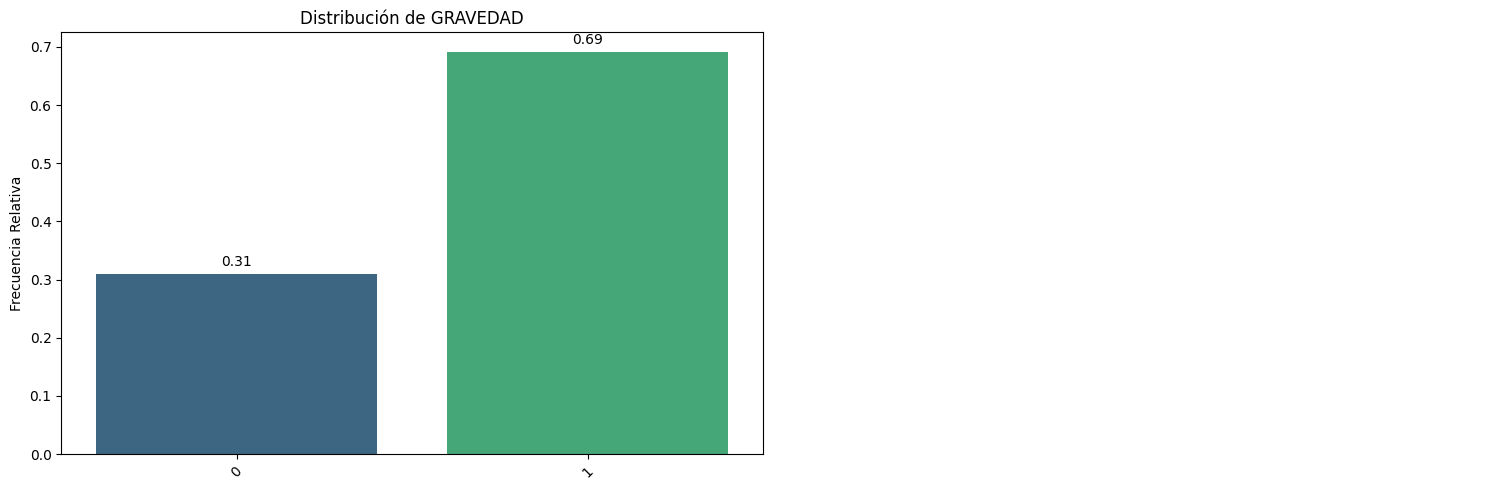

In [11]:
bt.pinta_distribucion_categoricas(df, [target], mostrar_valores = True, relativa = True)

In [ ]:
# Separamos el dataset en train y test 

train_set, test_set = train_test_split(df, test_size = 0.2, random_state = 42, stratify=df["GRAVEDAD"])

In [ ]:
# Analizamos la correlación de la variable target con las variables numericas

corr = train_set.corr(numeric_only= "True")
serie_corr = np.abs(corr[target]).sort_values(ascending = False)
serie_corr

GRAVEDAD            1.000000
PUNTOS              0.808432
CUANTIA             0.287039
NUM_INFRACCIONES    0.100446
Name: GRAVEDAD, dtype: float64

## Estrategia de preprocesado

Los modelos de Machine Learning requieren que las variables estén representadas en formato numérico.

Por este motivo es necesario transformar las variables categóricas mediante técnicas de **encoding**.

Se utilizan diferentes tipos de codificación dependiendo de la naturaleza de cada variable:

- **Get_dummies** para variables binarias
- **Ordinal encoding** para variables con orden natural

In [ ]:
# La variable SEXO se codifica como binaria ya que solo contiene dos categorías posibles.

pd.get_dummies(train_set["SEXO"], columns="SEXO", drop_first=True, dtype=int)

,V
103124,0
16281,1
29600,0
116042,1
177848,1
...,...
61344,1
291454,1
178534,0
118582,1


In [ ]:
train_set["SEXO"] = (train_set["SEXO"] == "V").astype(int) # V -> clase 1, M -> clase 0
test_set["SEXO"] = (test_set["SEXO"] == "V").astype(int) # V -> clase 1, M -> clase 0

In [16]:
train_set["SEXO"].value_counts()

SEXO
1    174197
0     77990
Name: count, dtype: int64

In [ ]:
# La variable NOVEL también se transforma mediante codificación binaria porque indica simplemente si el conductor es novel o no.

pd.get_dummies(train_set["NOVEL"], columns="NOVEL", drop_first=True, dtype=int)

,SI
103124,0
16281,0
29600,0
116042,0
177848,0
...,...
61344,0
291454,0
178534,0
118582,0


In [18]:
train_set["NOVEL"] = (train_set["NOVEL"] == "SI").astype(int) # SI -> clase 1, NO -> clase 0
test_set["NOVEL"] = (test_set["NOVEL"] == "SI").astype(int) # SI -> clase 1, NO -> clase 0

In [19]:
train_set["NOVEL"].value_counts()

NOVEL
0    239761
1     12426
Name: count, dtype: int64

In [20]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 252187 entries, 103124 to 221009
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   CUANTIA           252187 non-null  float64
 1   PUNTOS            252187 non-null  int64  
 2   SEXO              252187 non-null  int64  
 3   NOVEL             252187 non-null  int64  
 4   EDAD              252187 non-null  object 
 5   NUM_INFRACCIONES  252187 non-null  int64  
 6   GRAVEDAD          252187 non-null  int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 15.4+ MB


In [21]:
df["EDAD"].value_counts()

EDAD
De 35 a 44 años    67131
De 25 a 34 años    66768
De 45 a 54 años    61598
De 55 a 64 años    44287
 Hasta 24 años     37512
De 65 a 74 años    24938
Más de 74 años     13000
Name: count, dtype: int64

In [ ]:
# La variable EDAD se trata como una variable ordinal ya que existe un orden natural entre los distintos rangos de edad.

oe = OrdinalEncoder(categories=[[" Hasta 24 años", "De 25 a 34 años", "De 35 a 44 años", "De 45 a 54 años", "De 55 a 64 años", "De 65 a 74 años", "Más de 74 años"]])

train_set["EDAD"] = oe.fit_transform(train_set[["EDAD"]])
test_set["EDAD"] = oe.transform(test_set[["EDAD"]])

In [23]:
train_set["EDAD"] = train_set["EDAD"].astype(int)
test_set["EDAD"] = test_set["EDAD"].astype(int)
train_set["EDAD"].value_counts()

EDAD
2    53730
1    53389
3    49285
4    35395
0    29981
5    20056
6    10351
Name: count, dtype: int64

In [24]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 252187 entries, 103124 to 221009
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   CUANTIA           252187 non-null  float64
 1   PUNTOS            252187 non-null  int64  
 2   SEXO              252187 non-null  int64  
 3   NOVEL             252187 non-null  int64  
 4   EDAD              252187 non-null  int64  
 5   NUM_INFRACCIONES  252187 non-null  int64  
 6   GRAVEDAD          252187 non-null  int64  
dtypes: float64(1), int64(6)
memory usage: 15.4 MB


In [25]:
# Separo X e Y

X_train = train_set.drop(columns=["GRAVEDAD", "PUNTOS", "CUANTIA"])  # Quitamos las columnas que estan totalmente relacionadas con la gravedad para que no filtren información
y_train = train_set["GRAVEDAD"]

X_test = test_set.drop(columns=["GRAVEDAD", "PUNTOS", "CUANTIA"])
y_test = test_set["GRAVEDAD"]

In [26]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(252187, 4) (252187,)
(63047, 4) (63047,)


## Comparativa de modelos

En esta fase se comparan diferentes algoritmos de clasificación con el objetivo de identificar cuál ofrece mejor rendimiento para este problema.

Entre los modelos evaluados se encuentran distintos algoritmos de clasificación como LogisticRegression, RandomForest o LightGBM.

La métrica utilizada para la comparación es **recall**, ya que el objetivo principal es detectar el mayor número posible de infracciones graves.

Los falsos negativos (no detectar una infracción grave) tienen un coste mayor que los falsos positivos, por lo que maximizar el recall es prioritario.

In [ ]:
from sklearn.pipeline import Pipeline

lr_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, class_weight="balanced"))
])

rf_clf = Pipeline([
    ('model', RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1, class_weight="balanced"))
])

lgb_clf_base = Pipeline([
    ('model', LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=31, random_state=42, n_jobs=-1, verbose=-1, class_weight="balanced"))
])

modelos_clf = {
    "Regresion Logistica": lr_clf,
    "Random Forest": rf_clf,
    "LightGBM": lgb_clf_base
}

In [28]:
for tipo, modelo in modelos_clf.items():
    print(f"{tipo}: ", end=" ")
    print(np.mean(cross_val_score(modelo, X_train, y_train, cv=5, scoring="recall")))

Regresion Logistica:  0.600514417302124
Random Forest:  0.6992863370471983
LightGBM:  0.7009742686858834


## Resultados de la comparativa

Tras evaluar los distintos modelos se observa que **LightGBM** ofrece el mejor rendimiento en términos de recall.

Además de su buen rendimiento predictivo, LightGBM presenta otras ventajas:

- buena capacidad para manejar datasets grandes
- entrenamiento rápido
- capacidad para capturar relaciones complejas entre variables

Por estos motivos se selecciona este modelo para la fase de optimización de hiperparámetros.

In [29]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
# Modelo sencillo sin ajustar todos los hiperparametros de LightGBM

from sklearn.metrics import recall_score, f1_score, classification_report

lgb_base = LGBMClassifier(
    class_weight="balanced",   
    random_state=42,
    n_jobs=-1,
    verbose=-1)

lgb_base.fit(X_train, y_train)
y_pred = lgb_base.predict(X_test)

print("Recall test:", recall_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Recall test: 0.6947295900792284
F1 test: 0.7236887745948208
              precision    recall  f1-score   support

           0       0.42      0.50      0.46     19502
           1       0.76      0.69      0.72     43545

    accuracy                           0.63     63047
   macro avg       0.59      0.60      0.59     63047
weighted avg       0.65      0.63      0.64     63047



## Optimización de hiperparámetros

Para mejorar el rendimiento del modelo se realiza una búsqueda de hiperparámetros utilizando **RandomizedSearchCV**.

Se utiliza RandomizedSearch en lugar de GridSearch porque:

- permite explorar un espacio de hiperparámetros más amplio
- reduce significativamente el tiempo de entrenamiento
- es más eficiente cuando el número de combinaciones posibles es elevado

Durante la búsqueda se exploran diferentes valores para hiperparámetros relevantes del modelo como la profundidad de los árboles, el número de estimadores y la tasa de aprendizaje.

In [ ]:
lgb_clf = Pipeline([
    ("lgb", LGBMClassifier(
        random_state=42,
        verbose=-1,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

param_distributions = {
    "lgb__n_estimators": randint(200, 900),
    "lgb__learning_rate": uniform(0.01, 0.19),
    "lgb__num_leaves": randint(16, 128),
    "lgb__min_child_samples": randint(10, 150),
    "lgb__max_depth": randint(-1, 21),
    "lgb__subsample": uniform(0.7, 0.3),
    "lgb__reg_alpha": uniform(0.0, 0.3),
    "lgb__reg_lambda": uniform(0.0, 2.0)
}

lgb_random = RandomizedSearchCV(
    estimator=lgb_clf,
    param_distributions=param_distributions,
    n_iter=40,
    scoring="recall",
    cv=cv,
    n_jobs=1,
    verbose=2,
    random_state=42
)

lgb_random.fit(X_train, y_train)


Fitting 5 folds for each of 40 candidates, totalling 200 fits
[CV] END lgb__learning_rate=0.08116262258099886, lgb__max_depth=13, lgb__min_child_samples=116, lgb__n_estimators=271, lgb__num_leaves=76, lgb__reg_alpha=0.1790550473839461, lgb__reg_lambda=0.8916655057071823, lgb__subsample=0.7299924747454009; total time=   1.3s
[CV] END lgb__learning_rate=0.08116262258099886, lgb__max_depth=13, lgb__min_child_samples=116, lgb__n_estimators=271, lgb__num_leaves=76, lgb__reg_alpha=0.1790550473839461, lgb__reg_lambda=0.8916655057071823, lgb__subsample=0.7299924747454009; total time=   1.0s
[CV] END lgb__learning_rate=0.08116262258099886, lgb__max_depth=13, lgb__min_child_samples=116, lgb__n_estimators=271, lgb__num_leaves=76, lgb__reg_alpha=0.1790550473839461, lgb__reg_lambda=0.8916655057071823, lgb__subsample=0.7299924747454009; total time=   0.9s
[CV] END lgb__learning_rate=0.08116262258099886, lgb__max_depth=13, lgb__min_child_samples=116, lgb__n_estimators=271, lgb__num_leaves=76, lgb__re

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('lgb',
                                              LGBMClassifier(class_weight='balanced',
                                                             n_jobs=-1,
                                                             random_state=42,
                                                             verbose=-1))]),
                   n_iter=40, n_jobs=1,
                   param_distributions={'lgb__learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001D420CFB230>,
                                        'lgb__max_dept...
                                        'lgb__num_leaves': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001D42193F610>,
                                        'lgb__reg_alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001D42193F250>,
                                        'lgb__reg_lambda': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001D420D12C40>,
                                        'lgb__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001D42193E990>},
                   random_state=42, scoring='recall', verbose=2)

## Mejores hiperparámetros encontrados

Tras el proceso de búsqueda se obtienen los hiperparámetros que ofrecen el mejor rendimiento según la métrica definida:

In [32]:
print("Mejores params:", lgb_random.best_params_)
print("Mejor recall (CV):", lgb_random.best_score_)

Mejores params: {'lgb__learning_rate': np.float64(0.06311646494138413), 'lgb__max_depth': 4, 'lgb__min_child_samples': 108, 'lgb__n_estimators': 236, 'lgb__num_leaves': 39, 'lgb__reg_alpha': np.float64(0.09922509140115411), 'lgb__reg_lambda': np.float64(1.1055299336709798), 'lgb__subsample': np.float64(0.8716877407512514)}
Mejor recall (CV): 0.7068589933914624


## Ajuste del umbral de decisión

Reducir el threshold permite **aumentar el recall**, ya que el modelo clasificará más casos como infracciones graves.

Esto puede hacer que aumente el número de falsos positivos, pero nos permite detectar más casos potencialmente peligrosos.

Tras varias pruebas, en este modelo hemos decidido utilizar un threshold de 0.52 para encontrar un equilibrio adecuado entre recall y precisión.

In [33]:
best_model = lgb_random.best_estimator_
y_proba = best_model.predict_proba(X_test)[:, 1]

for t in [0.45, 0.5, 0.55, 0.6]:
    y_t = (y_proba >= t).astype(int)
    print(
        f"t={t:0.2f}",
        "recall:", round(recall_score(y_test, y_t), 3),
        "precision:", round(precision_score(y_test, y_t), 3)
    )

t_final = 0.52
y_pred_final = (y_proba >= t_final).astype(int)
print(classification_report(y_test, y_pred_final))

t=0.45 recall: 0.814 precision: 0.744
t=0.50 recall: 0.706 precision: 0.754
t=0.55 recall: 0.502 precision: 0.776
t=0.60 recall: 0.339 precision: 0.793
              precision    recall  f1-score   support

           0       0.41      0.55      0.47     19502
           1       0.76      0.64      0.69     43545

    accuracy                           0.61     63047
   macro avg       0.58      0.59      0.58     63047
weighted avg       0.65      0.61      0.62     63047



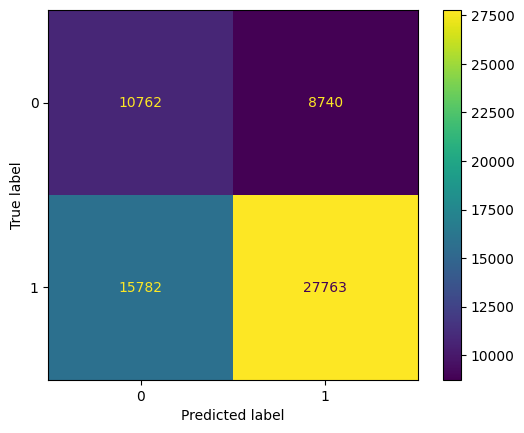

In [36]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final)

plt.show()

## Interpretación de resultados

En este caso los resultados obtenidos son:

- **27.763 infracciones graves correctamente detectadas (Verdaderos Positivos).**
- **15.782 infracciones graves que el modelo no detecta (Falsos Negativos).**
- **10.762 infracciones no graves correctamente clasificadas (Verdaderos Negativos).**
- **8.740 infracciones no graves clasificadas como graves (Falsos Positivos).**


Desde el punto de vista del negocio, el objetivo es detectar el mayor número posible de infracciones graves sin penalizar a un gran número de conductores que tiene infracciones leves.

Este modelo reduce de forma considerable el número de falsos positivos, es decir, el número de conductores que serían clasificados como de alto riesgo sin serlo realmente. Para una aseguradora esto es especialmente importante, ya que penalizar injustamente a muchos clientes puede afectar negativamente a la fidelización y provocar la pérdida de clientes.

Al mismo tiempo, el modelo sigue siendo capaz de detectar un número elevado de infracciones graves (27.763 casos), lo que permite identificar una proporción significativa de situaciones potencialmente peligrosas, aunque se pierda parte de ellas.

Por tanto, este modelo representa un equilibrio más adecuado entre detección de casos graves y reducción de clientes perjudicados injustamente, lo que lo convierte en una opción muy razonable desde el punto de vista del negocio.

## Guardamos el modelo

In [35]:
import pickle

with open('src/models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)